# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

# Load Dataset

In [4]:
df = pd.read_csv('house_price.csv')

# Data Overview

In [5]:
df.head()

,House_Size_sqft,Bedrooms,House_Price
0,1078.0,5.0,2689034.0
1,3372.0,1.0,1090751.0
2,803.0,4.0,2325280.0
3,1483.0,2.0,1461283.0
4,639.0,4.0,1980237.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   House_Size_sqft  88 non-null     float64
 1   Bedrooms         95 non-null     float64
 2   House_Price      94 non-null     float64
dtypes: float64(3)
memory usage: 2.5 KB


In [7]:
df.describe()

,House_Size_sqft,Bedrooms,House_Price
count,88.000000,95.000000,9.400000e+01
mean,2190.159091,2.915789,1.844049e+06
std,883.954983,1.456191,7.322274e+05
min,639.000000,1.000000,4.596490e+05
25%,1367.000000,2.000000,1.277749e+06
50%,2294.500000,3.000000,1.716347e+06
75%,3046.000000,4.000000,2.505013e+06
max,3487.000000,5.000000,3.276338e+06


In [8]:
df.isnull().sum()

,0
House_Size_sqft,12
Bedrooms,5
House_Price,6


## Handling Missing Values

In [9]:
df['House_Size_sqft'].skew()

np.float64(-0.18843168037997285)

In [10]:
df['House_Size_sqft'] = df['House_Size_sqft'].fillna(df['House_Size_sqft'].mean())

In [11]:
df['House_Size_sqft'].isnull().sum()

np.int64(0)

In [12]:
df['Bedrooms'].skew()

np.float64(0.17037987778868324)

In [13]:
df['Bedrooms'] = df['Bedrooms'].fillna(df['Bedrooms'].mean())

In [14]:
df['Bedrooms'].isnull().sum()

np.int64(0)

In [15]:
df['House_Price'].skew()

np.float64(0.21760171261393982)

In [16]:
df['House_Price'] = df['House_Price'].fillna(df['House_Price'].mean())

In [17]:
df.isnull().sum()

,0
House_Size_sqft,0
Bedrooms,0
House_Price,0


# Visulization

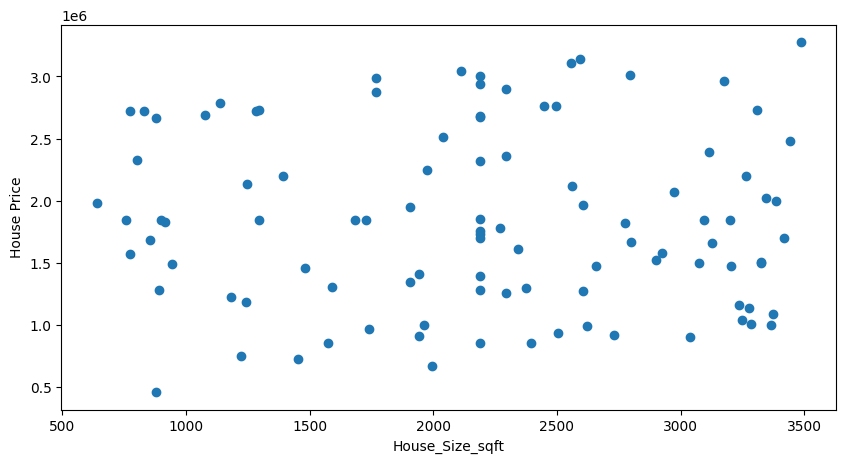

In [78]:
plt.figure(figsize=(10,5))
plt.scatter(df['House_Size_sqft'],df['House_Price'])
plt.xlabel('House_Size_sqft')
plt.ylabel('House Price')
plt.show()

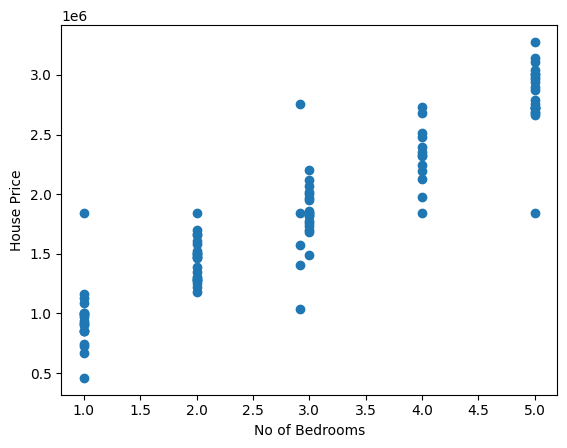

In [24]:
plt.scatter(df['Bedrooms'],df['House_Price'])
plt.xlabel("No of Bedrooms")
plt.ylabel('House Price')
plt.show()

# Data Preprocessing

In [25]:
x = df[['House_Size_sqft','Bedrooms']]
y = df['House_Price']

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

# Model

In [27]:
model = LinearRegression()

In [28]:
model.fit(x_train,y_train)

LinearRegression()

In [29]:
y_pred = model.predict(x_test)

In [34]:
comparision = pd.DataFrame({'Actual':y_test, "Prediction":y_pred.round(2)})
comparision.head()

,Actual,Prediction
83,1948108.0,1870183.33
53,1685097.0,1756291.27
70,2071636.0,1985915.86
45,2722035.0,2782023.18
44,2680028.0,2390536.62


In [36]:
error = y_test-y_pred

In [38]:
results = pd.DataFrame({'Actual':y_test,
                        "Prediction":y_pred.round(2),
                        "Error":error.round(2)})
results.head(5)

,Actual,Prediction,Error
83,1948108.0,1870183.33,77924.67
53,1685097.0,1756291.27,-71194.27
70,2071636.0,1985915.86,85720.14
45,2722035.0,2782023.18,-59988.18
44,2680028.0,2390536.62,289491.38


In [45]:
error.mean()

np.float64(-62678.349896564585)

# Model Evaluation

In [48]:
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
evalution = pd.DataFrame({"MSE":[round(mse,2)],
                          "RMSE":[round(rmse,2)],
                          "R2":[round(r2,2)]})

evalution

,MSE,RMSE,R2
0,6.344042e+10,251873.83,0.85


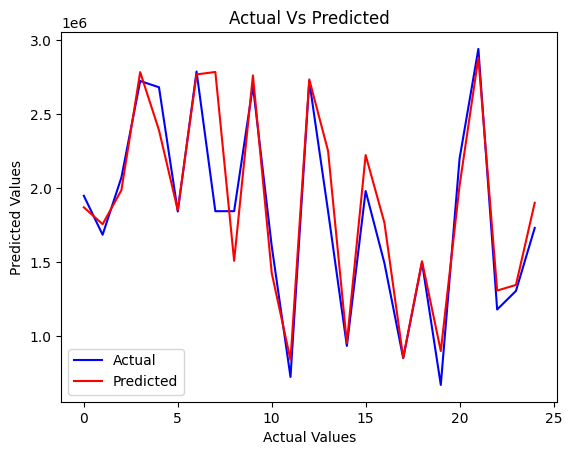

In [72]:
plt.plot(y_test.values,label="Actual",color="blue")
plt.plot(y_pred,label="Predicted",color="red")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual Vs Predicted")
plt.legend()
plt.show()

In [ ]:
New_pred = pd.DataFrame({"House_Size_sqft":[1500],
                         "Bedrooms":[2]})
new_pred=pd.DataFrame({"Prediction":model.predict(New_pred).round(2)
})
new_pred

,Prediction
0,1336639.25
